# Stage 0 — Study 3: Frequency-Band Sensitivity and the Resolution Hypothesis

**Goal.** The original EvolBA paper initialises attacks by blending *high-frequency* fractal
texture into the original image, motivated by the finding that CNNs rely heavily on
high-frequency features. Our report (`report.tex`, §"Setting") argues this may transfer poorly
to CIFAR-10's 32×32 images: with only 32 frequency bins per axis (a 7× coarser grid than
ImageNet's 224), "structure" and "texture" are squeezed into a much narrower band, and each
high-frequency component "occupies a disproportionately large share of the image". This claim
was so far supported only indirectly (comparing two pre-built corruptions — JPEG vs. Gaussian
high-frequency noise — whose perturbation *shapes* differ in more than just frequency content).

This study tests the claim directly, in two parts:

* **Part A — band sensitivity sweep (model-dependent).** Inject noise confined to a single,
  controlled frequency band (defined by *normalized* radial frequency, so the definition is
  resolution-independent) and binary-search the minimum perturbation energy that flips the
  prediction of each WRN-28-10 model (standard / robust). This produces a clean, single-axis
  "which frequencies does the model actually rely on, and at what perceptual cost" curve —
  replacing the old confounded JPEG-vs-noise comparison.

* **Part B — does resolution change the cost of high-frequency injection? (model-independent).**
  Rescale the *same* images to several resolutions, inject the *same normalized* amount of
  perturbation energy into the *same normalized* frequency band at each scale, and measure the
  resulting SSIM drop. If the report's claim is right, the perceptual cost of high-frequency
  injection should fall off measurably faster than that of low-frequency injection as resolution
  grows — turning a plausible argument into a measured curve (and, if it *isn't* the case,
  telling us the explanation needs revision).

Both models are evaluated with batched, GPU-vectorised forward passes — the binary searches in
Part A are run for *all* (image, band) pairs simultaneously rather than one query at a time.

In [1]:
# ── imports ───────────────────────────────────────────────────────────────────
import os, time, random, warnings
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
from scipy.fft import dctn, idctn
from skimage.metrics import structural_similarity as ski_ssim
from skimage.transform import resize as sk_resize
from robustbench.utils import load_model as rb_load_model

warnings.filterwarnings('ignore')   # robustbench/skimage emit noisy version-mismatch warnings

# ── config ────────────────────────────────────────────────────────────────────
SEED       = 42
N_IMAGES   = 150     # images jointly correctly classified by both models (Part A)
BS_STEPS   = 12      # binary-search steps; precision = MAG_MAX / 2**BS_STEPS
MAG_MAX    = 24.0    # ceiling on injected-perturbation L2 magnitude (Part A)
OUTPUT_DIR = './outputs/study3_frequency'
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)   # reproducible image/direction sampling
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']
# normalisation stats for the *standard* model only -- the robust model normalises internally (see next cell)
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2471, 0.2435, 0.2616)

/home/tomma/EvolBA/EV_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


In [2]:
# CIFAR-10 test split as raw [0, 1] float tensors; per-model normalisation is applied
# right before each forward pass (see norm_std / norm_rob below) so we can share one image batch.
test_dataset = torchvision.datasets.CIFAR10(
    root='../data', train=False, download=True, transform=T.ToTensor(),
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
print(f'Test set: {len(test_dataset)} images')

# load both target models from RobustBench's model zoo (cached locally after the first download)
print('Loading Standard WRN-28-10...')
std_model = rb_load_model(model_name='Standard', dataset='cifar10', threat_model='Linf').to(device).eval()
print('Loading Robust WRN-28-10 (Wang2023Better, TRADES)...')
rob_model = rb_load_model(model_name='Wang2023Better_WRN-28-10', dataset='cifar10', threat_model='Linf').to(device).eval()

# each model is paired with its own input-normalisation function, since the two were trained differently
mean_t = torch.tensor(CIFAR10_MEAN, device=device).view(1, 3, 1, 1)
std_t  = torch.tensor(CIFAR10_STD,  device=device).view(1, 3, 1, 1)
def norm_std(x): return (x - mean_t) / std_t
def norm_rob(x): return x   # Wang2023Better normalises internally

MODELS = {'standard': (std_model, norm_std), 'robust': (rob_model, norm_rob)}
print('Models ready:', list(MODELS.keys()))

Test set: 10000 images
Loading Standard WRN-28-10...


Loading Robust WRN-28-10 (Wang2023Better, TRADES)...


Models ready: ['standard', 'robust']


In [3]:
@torch.no_grad()
def batched_predict(model, norm_fn, x_chw_batch: np.ndarray, chunk: int = 512) -> np.ndarray:
    """x_chw_batch: (N, C, H, W) float32 in [0,1]  ->  (N,) int array of predicted labels.

    Runs the whole batch through the GPU in chunks -- this is the key efficiency lever for
    this study: every binary-search step below queries hundreds of (image, band) candidates
    in a *single* forward pass instead of one model call per candidate.
    """
    preds = []
    for i in range(0, len(x_chw_batch), chunk):
        xb = torch.from_numpy(x_chw_batch[i:i + chunk]).float().to(device)
        preds.append(model(norm_fn(xb)).argmax(1).cpu().numpy())
    return np.concatenate(preds)


def clip01(x):
    return np.clip(x, 0., 1.).astype(np.float32)


# Walk the test set and keep only images BOTH models already classify correctly --
# otherwise a "successful" boundary crossing could just mean "the model was already wrong",
# which would silently inflate reach rates and distort the SSIM/L2 statistics below.
selected_images: List[np.ndarray] = []
selected_labels: List[int] = []
for imgs, labels_b in test_loader:
    x_np = imgs.numpy()
    p_std = batched_predict(*MODELS['standard'], x_np)
    p_rob = batched_predict(*MODELS['robust'], x_np)
    mask = (p_std == labels_b.numpy()) & (p_rob == labels_b.numpy())
    for i in np.where(mask)[0]:
        selected_images.append(x_np[i])
        selected_labels.append(int(labels_b[i]))
        if len(selected_images) >= N_IMAGES:
            break
    if len(selected_images) >= N_IMAGES:
        break

images = np.stack(selected_images).astype(np.float32)   # (N, C, H, W)
labels = np.array(selected_labels, dtype=np.int64)
print(f'Selected {len(images)} images jointly correct on both models. Shape: {images.shape}')

Selected 150 images jointly correct on both models. Shape: (150, 3, 32, 32)


## Part A — Band Sensitivity Sweep

**Idea.** Define a handful of frequency bands by *normalized radial frequency*
$\rho = \sqrt{(f_y/H)^2 + (f_x/W)^2}/\sqrt{2} \in [0, 1)$ in the 2D DCT domain — this is exactly
"cycles per pixel" and so is comparable across resolutions. For each band, generate a unit-L2
spatial direction whose DCT energy is confined to that band (random coefficients within the
band, masked elsewhere, inverse-transformed) — i.e. controlled-frequency noise. Then, for every
(image, band) pair and both models, **binary-search the minimum perturbation magnitude that
flips the prediction**, and record SSIM / L2 / L∞ at that boundary.

The result is a single, clean curve per model: *"how much perturbation energy — and at what
perceptual (SSIM) cost — does it take to cross the decision boundary using only frequency
content from band X?"* This directly measures which frequencies the CIFAR-WRN models are
sensitive to (replacing the old, confounded JPEG-vs-Gaussian-noise comparison from the original
Stage 0), independent of any particular corruption's incidental structure.

In [4]:
def radial_freq_grid(H: int, W: int) -> np.ndarray:
    """Normalized radial frequency rho[fy, fx] = "cycles per pixel" magnitude, in [0, ~1).
    Resolution-independent: the same rho always corresponds to the same spatial wavelength
    (in pixels), regardless of image size -- this is what makes bands comparable across scales.
    """
    fy = np.arange(H)[:, None] / H
    fx = np.arange(W)[None, :] / W
    return np.sqrt(fy**2 + fx**2) / np.sqrt(2)


# Five equal-width bands spanning the spectrum; the DC term (rho=0, "uniform shift" /
# brightness) is excluded since it is already covered by the brightness/contrast corruptions
# studied previously -- here we want pure spatial *texture* content.
BAND_EDGES = [(1e-6, 0.20), (0.20, 0.40), (0.40, 0.60), (0.60, 0.80), (0.80, 1.01)]
BAND_NAMES = ['B1 low', 'B2 low-mid', 'B3 mid', 'B4 mid-high', 'B5 high']


def band_mask(rho: np.ndarray, lo: float, hi: float) -> np.ndarray:
    return (rho >= lo) & (rho < hi)


def band_direction(shape_chw: tuple, mask: np.ndarray, seed: int) -> np.ndarray:
    """Unit-L2-norm spatial pattern whose 2D-DCT energy is confined to `mask`.

    Random DCT coefficients are drawn within the band, zeroed elsewhere, and inverse-
    transformed -- i.e. "band-limited white noise" with a controlled, resolution-independent
    spatial frequency content.
    """
    C, H, W = shape_chw
    rng = np.random.default_rng(seed)
    direction = np.empty(shape_chw, dtype=np.float64)
    for c in range(C):
        coeffs = rng.standard_normal((H, W)) * mask
        direction[c] = idctn(coeffs, norm='ortho')
    direction /= (np.linalg.norm(direction) + 1e-12)
    return direction.astype(np.float32)


# pre-compute the frequency grid and one boolean mask per band -- shared by every image/seed below
C, H, W = images.shape[1:]
RHO   = radial_freq_grid(H, W)
MASKS = [band_mask(RHO, lo, hi) for lo, hi in BAND_EDGES]
print('DCT coefficients per band (per channel):', [int(m.sum()) for m in MASKS],
      f'  (total {H*W} per channel)')

DCT coefficients per band (per channel): [72, 204, 329, 342, 76]   (total 1024 per channel)


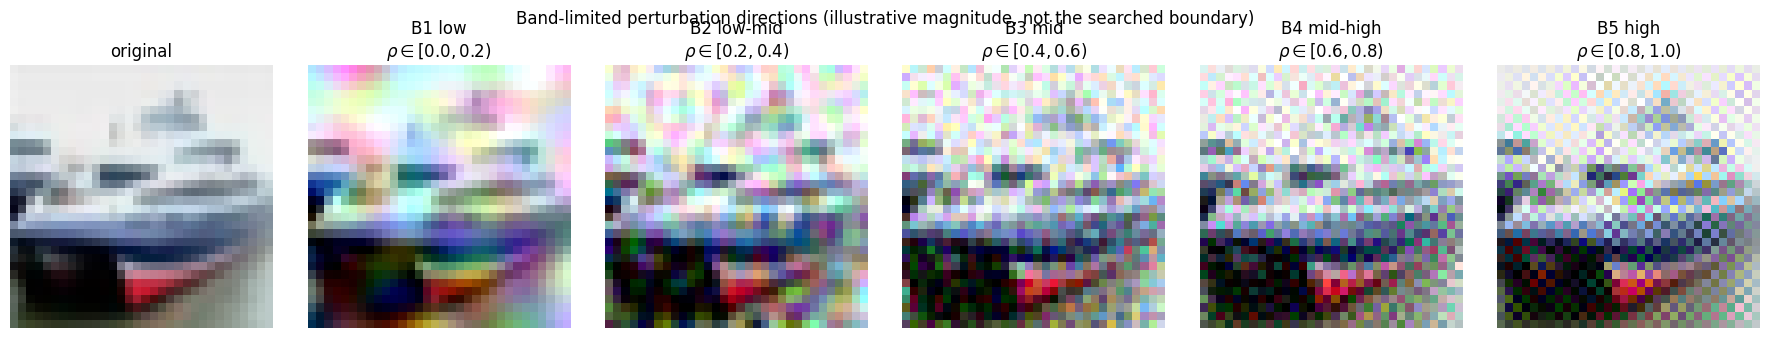

In [5]:
# Sanity check: render what each band's noise actually looks like. The directions are scaled
# up 6x here purely so they're visible -- this is *not* the (much smaller) magnitude that the
# boundary search below will actually use; it's just a visual confirmation that "low" looks like
# smooth blobs and "high" looks like fine checkerboard texture, as the rho definition intends.
fig, axes = plt.subplots(1, len(BAND_EDGES) + 1, figsize=(3.0 * (len(BAND_EDGES) + 1), 3.4))
example = images[0]
axes[0].imshow(example.transpose(1, 2, 0)); axes[0].set_title('original'); axes[0].axis('off')
for bi, (mask, name, (lo, hi)) in enumerate(zip(MASKS, BAND_NAMES, BAND_EDGES)):
    d = band_direction((C, H, W), mask, seed=SEED + bi)
    shown = clip01(example + 6.0 * d)
    axes[bi + 1].imshow(shown.transpose(1, 2, 0))
    axes[bi + 1].set_title(f'{name}\n$\\rho \\in [{lo:.1f}, {hi:.1f})$')
    axes[bi + 1].axis('off')
plt.suptitle('Band-limited perturbation directions (illustrative magnitude, not the searched boundary)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/band_directions_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
def build_directions(imgs: np.ndarray, masks: List[np.ndarray], seed_base: int) -> np.ndarray:
    """One unit-norm band-limited direction per (image, band): (N, B, C, H, W)."""
    N = len(imgs)
    shape_chw = imgs.shape[1:]
    dirs = np.empty((N, len(masks)) + shape_chw, dtype=np.float32)
    for i in range(N):
        for bi, mask in enumerate(masks):
            dirs[i, bi] = band_direction(shape_chw, mask, seed=seed_base + i * 1009 + bi * 131)
    return dirs


def vectorized_band_boundary_search(model, norm_fn, imgs, lbls, directions, mag_max, bs_steps):
    """
    Fully-batched binary search over perturbation magnitude, run for *every* (image, band)
    pair at once: each of the (bs_steps + 1) loop iterations is a single batched forward pass
    over all P = N_images * N_bands candidates, rather than P * (bs_steps + 1) individual
    queries -- this is the GPU-efficient formulation of the per-image binary search.

    Returns dict with (N, B)-shaped `hi` (boundary magnitude) and `reached` (bool), and the
    (N, B, C, H, W) boundary images.
    """
    N, Bn = directions.shape[:2]
    P = N * Bn
    base = np.repeat(imgs, Bn, axis=0)                      # (P, C, H, W) -- each image repeated once per band
    dirs = directions.reshape(P, *directions.shape[2:])     # (P, C, H, W) -- matching flat list of directions
    y    = np.repeat(lbls, Bn)                              # (P,)         -- matching flat list of true labels

    def make(mag):
        return clip01(base + mag[:, None, None, None] * dirs)

    # First check whether the magnitude ceiling crosses the boundary at all (one batched pass) --
    # pairs that don't reach it within MAG_MAX are flagged via `reached` rather than searched forever.
    p_hi    = batched_predict(model, norm_fn, make(np.full(P, mag_max)))
    reached = (p_hi != y)

    # Standard bisection on the scalar magnitude, run in lockstep across all P pairs: each
    # iteration halves [lo, hi] for every pair simultaneously using one batched forward pass.
    lo = np.zeros(P, dtype=np.float64)
    hi = np.full(P, mag_max, dtype=np.float64)
    for _ in range(bs_steps):
        mid    = 0.5 * (lo + hi)
        is_adv = (batched_predict(model, norm_fn, make(mid)) != y)
        hi = np.where(is_adv, mid, hi)
        lo = np.where(is_adv, lo, mid)

    return {
        'hi':         hi.reshape(N, Bn),
        'reached':    reached.reshape(N, Bn),
        'x_boundary': make(hi).reshape(N, Bn, *imgs.shape[1:]),
    }


DIRECTIONS = build_directions(images, MASKS, seed_base=SEED)
n_pairs    = len(images) * len(MASKS)
print(f'Directions: {DIRECTIONS.shape}  ->  {n_pairs} (image, band) pairs per model, '
      f'{BS_STEPS + 1} batched forward passes per model (vs. {n_pairs * (BS_STEPS + 1)} '
      f'individual queries with a naive per-pair loop).')

Directions: (150, 5, 3, 32, 32)  ->  750 (image, band) pairs per model, 13 batched forward passes per model (vs. 9750 individual queries with a naive per-pair loop).


### Run the sweep
The only GPU-heavy step in Part A — everything above was setup.

In [7]:
# Run the full vectorised search once per model. band_results[model] holds, for every
# (image, band) pair: the boundary magnitude `hi`, whether it was `reached` within MAG_MAX,
# and the actual boundary image `x_boundary` (used for SSIM/L2/Linf below).
band_results = {}
t0 = time.time()
for mname, (model, norm_fn) in MODELS.items():
    t1 = time.time()
    res = vectorized_band_boundary_search(model, norm_fn, images, labels, DIRECTIONS, MAG_MAX, BS_STEPS)
    band_results[mname] = res
    print(f'  {mname:9s}: reach rate = {res["reached"].mean():5.1%}   '
          f'({time.time() - t1:.1f}s, {n_pairs} pairs x {BS_STEPS + 1} batched passes)')
print(f'Total: {time.time() - t0:.1f}s')

  standard : reach rate = 80.0%   (9.8s, 750 pairs x 13 batched passes)


  robust   : reach rate = 89.6%   (11.1s, 750 pairs x 13 batched passes)
Total: 20.9s


In [8]:
def ssim_chw(a, b):
    return float(ski_ssim(a.transpose(1, 2, 0), b.transpose(1, 2, 0), data_range=1.0, channel_axis=2))

# Flatten (model x image x band) results into one tidy long-format dataframe: one row per
# triple, carrying whether the search reached the boundary and the perceptual/energy metrics there.
rows = []
for mname, res in band_results.items():
    hi, reached, xb = res['hi'], res['reached'], res['x_boundary']
    for i in range(len(images)):
        for bi in range(len(MASKS)):
            x_orig, x_bnd = images[i], xb[i, bi]
            delta = x_bnd.astype(np.float64) - x_orig.astype(np.float64)
            rows.append(dict(
                model=mname, image_idx=i, band=bi, band_name=BAND_NAMES[bi],
                rho_lo=BAND_EDGES[bi][0], rho_hi=BAND_EDGES[bi][1],
                reached=bool(reached[i, bi]), magnitude=float(hi[i, bi]),
                ssim=ssim_chw(x_orig, x_bnd), l2=float(np.linalg.norm(delta)),
                linf=float(np.max(np.abs(delta))),
            ))

band_df = pd.DataFrame(rows)
band_df.to_parquet(f'{OUTPUT_DIR}/band_sensitivity.parquet')

# Headline numbers per (model, band): median perceptual cost (SSIM) and energy cost (L2/Linf)
# at the boundary -- restricted to pairs that actually reached it -- plus the overall reach rate.
reach_rate = band_df.groupby(['model', 'band_name'])['reached'].mean().rename('reach_rate')
quality    = (band_df[band_df['reached']]
              .groupby(['model', 'band_name'])[['ssim', 'l2', 'linf']]
              .median().rename(columns=lambda c: f'{c}_median'))
summary_A = quality.join(reach_rate).reindex(
    pd.MultiIndex.from_product([MODELS.keys(), BAND_NAMES], names=['model', 'band_name'])
).round(4)
print(summary_A)

                      ssim_median  l2_median  linf_median  reach_rate
model    band_name                                                   
standard B1 low            0.7265     4.3193       0.3114      0.7067
         B2 low-mid        0.8845     1.8841       0.1379      0.8133
         B3 mid            0.8433     2.3543       0.1559      0.8267
         B4 mid-high       0.8770     1.9914       0.1365      0.8267
         B5 high           0.9472     1.1279       0.0772      0.8267
robust   B1 low            0.5216     9.3151       0.6290      0.8800
         B2 low-mid        0.5111     8.5081       0.6021      0.9067
         B3 mid            0.4937     8.4395       0.5910      0.9067
         B4 mid-high       0.4782     9.0287       0.6037      0.8867
         B5 high           0.4589     9.4114       0.6397      0.9000


### Results

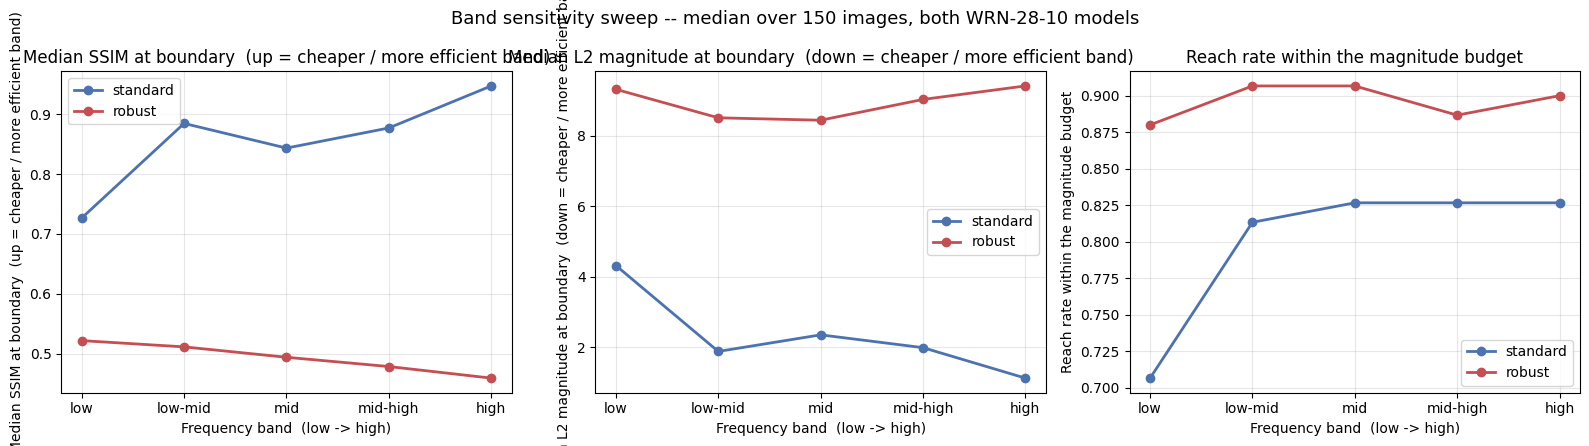

In [9]:
# Three views of the same sweep, each as a function of frequency band (low -> high):
# perceptual cost (SSIM, higher = cheaper), energy cost (L2, lower = cheaper), and whether
# the search even reached the boundary within the MAG_MAX budget.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
colors = {'standard': '#4C72B0', 'robust': '#C44E52'}
ok = band_df[band_df['reached']]

specs = [
    ('ssim',    'Median SSIM at boundary  (up = cheaper / more efficient band)'),
    ('l2',      'Median L2 magnitude at boundary  (down = cheaper / more efficient band)'),
    ('reached', 'Reach rate within the magnitude budget'),
]
for ax, (metric, ylabel) in zip(axes, specs):
    for mname, color in colors.items():
        if metric == 'reached':
            vals = band_df[band_df['model'] == mname].groupby('band_name')['reached'].mean().reindex(BAND_NAMES)
        else:
            vals = ok[ok['model'] == mname].groupby('band_name')[metric].median().reindex(BAND_NAMES)
        ax.plot(range(len(BAND_NAMES)), vals.values, marker='o', lw=2, color=color, label=mname)
    ax.set_xticks(range(len(BAND_NAMES)))
    ax.set_xticklabels([n.split(' ', 1)[1] for n in BAND_NAMES])
    ax.set_xlabel('Frequency band  (low -> high)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle(f'Band sensitivity sweep -- median over {len(images)} images, both WRN-28-10 models', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/band_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

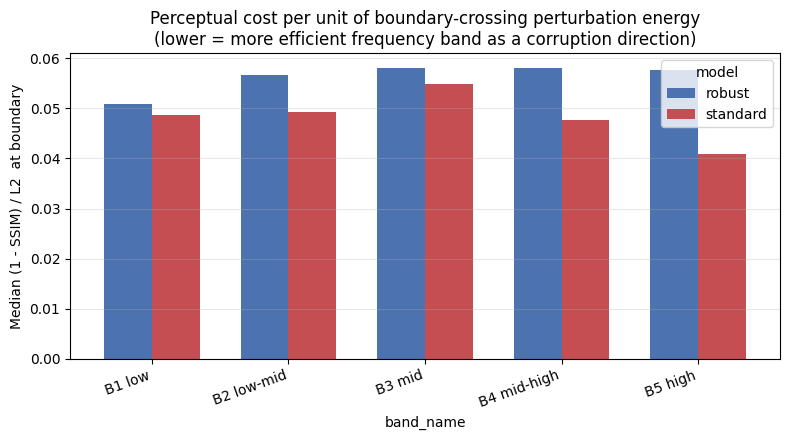

model        robust  standard
band_name                    
B1 low       0.0509    0.0486
B2 low-mid   0.0567    0.0494
B3 mid       0.0581    0.0549
B4 mid-high  0.0581    0.0477
B5 high      0.0577    0.0409


In [10]:
# Combine SSIM and L2 into a single "efficiency" axis: how much perceptual damage (1 - SSIM)
# is incurred per unit of boundary-crossing perturbation energy (L2). Lower = the band lets
# you reach the boundary "more cheaply" in perceptual terms -- i.e. a better Phase-1 init direction.
ok = ok.copy()
ok['ssim_cost_per_l2'] = (1.0 - ok['ssim']) / ok['l2'].clip(lower=1e-6)

eff = (ok.groupby(['model', 'band_name'])['ssim_cost_per_l2']
         .median().unstack('model').reindex(BAND_NAMES))
ax = eff.plot(kind='bar', figsize=(8, 4.5), color=[colors['standard'], colors['robust']], width=0.7)
ax.set_ylabel('Median (1 - SSIM) / L2  at boundary')
ax.set_title('Perceptual cost per unit of boundary-crossing perturbation energy\n(lower = more efficient frequency band as a corruption direction)')
ax.set_xticklabels(BAND_NAMES, rotation=20, ha='right')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/band_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

print(eff.round(4))

**Part A — reading the results.**

| model    | band       | SSIM @ boundary | L2 @ boundary | reach rate |
|----------|------------|----------------:|--------------:|-----------:|
| standard | B1 low     | 0.727 | 4.32 | 70.7% |
| standard | B2 low-mid | 0.885 | 1.88 | 81.3% |
| standard | B3 mid     | 0.843 | 2.35 | 82.7% |
| standard | B4 mid-high| 0.877 | 1.99 | 82.7% |
| standard | **B5 high**| **0.947** | **1.13** | 82.7% |
| robust   | **B1 low** | **0.522** | 9.32 | 88.0% |
| robust   | B2 low-mid | 0.511 | 8.51 | 90.7% |
| robust   | **B3 mid** | 0.494 | **8.44** | 90.7% |
| robust   | B4 mid-high| 0.478 | 9.03 | 88.7% |
| robust   | B5 high    | 0.459 | 9.41 | 90.0% |

* **Standard model: a clean, near-monotonic low→high trend, and high frequency is the *cheapest* band by every measure.** B5 needs the least boundary-crossing energy (median L2 = 1.13, vs. 4.32 for B1 — a **~4× difference**) *and* causes the least perceptual damage (SSIM = 0.947 vs. 0.727). In other words, pure high-frequency noise is the most "efficient" direction for crossing this model's decision boundary — exactly the opposite of what you'd guess from the fact that JPEG (which mostly *removes* high-frequency content) was the best-performing corruption-family member in the original Stage-0 study. Those results aren't actually contradictory: JPEG is a "natural-looking" degradation that humans tolerate well at a *given visual similarity*, whereas this experiment asks a different question — "which *frequency content*, injected as pure noise, gets you across the boundary most cheaply" — and the answer is unambiguously **high frequency**, consistent with the well-known finding that standard CNNs are highly sensitive to imperceptible high-frequency perturbations.

* **Robust model: the relationship is essentially flipped, and far flatter.** The *cheapest* band by perceptual cost is now **B1 (low)** (SSIM = 0.522) and by energy is **B3 (mid)** (L2 = 8.44); **B5 (high) is now the *worst* band on both axes** (SSIM = 0.459, L2 = 9.41). The band-to-band spread is also much smaller in relative terms (L2 ranges only 8.44–9.41, a ~10% spread, vs. a ~4× spread for the standard model) — this model's boundary looks comparatively **frequency-agnostic**.

* **The robust model is uniformly far harder to cross, regardless of band**: every band needs roughly **4–8× more L2 energy** and lands at **roughly half the SSIM** (≈0.46–0.52 vs. ≈0.73–0.95) compared to the standard model. This is exactly what TRADES-style adversarial training is designed to produce — a smoother, "fatter-margin" decision boundary — and the fact that *no* frequency band offers a meaningfully cheaper route through it suggests the smoothing acts fairly uniformly across the spectrum, not just at high frequencies.

* This directly supports a concrete, testable refinement to EvolBA's Phase 1: **for the standard model, a pure band-limited high-frequency direction would make a substantially better initializer than the current corruption families** — reaching the boundary with ~4× less perturbation energy and much higher SSIM (a better starting point for Phase 3 to refine from). **Against the robust model, however, no band offers a real advantage** — Phase 1's job there is mostly just "find *any* admissible starting point cheaply," and Phase 3 (the optimizer) will have to do essentially all of the actual work regardless of where Phase 1 lands. This also reframes the earlier "structure vs. texture squeezed into a narrow band" hypothesis: the dominant effect we observe isn't about *images* at all — it's about *which frequencies a given model's decision boundary is sensitive to*, and that differs sharply between standard and robustly-trained networks at the *same* resolution.

## Part B — Does Resolution Change the Cost of High-Frequency Injection?

**Idea.** Part A only tells us about *this* resolution. To test the report's resolution
argument directly we would ideally need a higher-resolution model — none is available in this
project (CIFAR-only). Instead we isolate the *purely perceptual* side of the claim, which needs
no model at all: take the **same images**, rescale them (bicubic) to several resolutions, inject
the **same normalized frequency band** at the **same relative magnitude** (constant per-pixel
RMS, so the "amount" of perturbation is comparable across scales), and measure the **SSIM drop**
at each resolution.

Because normalized frequency $\rho$ = "cycles per pixel" is resolution-independent (a band
defined by $\rho$ always corresponds to the *same spatial wavelength in pixels*, regardless of
image size — see the derivation in the band-sensitivity cell above), this gives a clean,
falsifiable test: if the report's claim is right, the **high**-frequency band's perceptual cost
should fall off with resolution noticeably faster than the **low**-frequency band's — since the
same texture-scale perturbation becomes a progressively smaller fraction of a progressively
larger image. If all bands behave similarly, the resolution-dependence explanation needs revising
(the effect the report observed may instead come from how natural images' own spectra are
distributed, or from the specific corruptions being compared, rather than a generic "HF occupies
a disproportionate share" mechanism).

In [11]:
RESOLUTIONS  = [32, 64, 128, 224]
# Three representative bands (skip the in-between B2/B4 to keep the cross-band comparison crisp)
RES_BANDS    = {'low  (rho < 0.2)': (1e-6, 0.20),
                'mid  (0.4 <= rho < 0.6)': (0.40, 0.60),
                'high (rho >= 0.8)': (0.80, 1.01)}
PERTURB_RMS  = [0.03, 0.06]   # target per-pixel RMS of the injected perturbation
N_RES_IMAGES = 60             # subset for the (larger-image) SSIM sweep

res_subset = images[:N_RES_IMAGES]


def resize_chw(img_chw: np.ndarray, size: int) -> np.ndarray:
    img_hwc = img_chw.transpose(1, 2, 0)
    out = sk_resize(img_hwc, (size, size, img_hwc.shape[2]), order=3, anti_aliasing=True, mode='reflect')
    return clip01(out.transpose(2, 0, 1))


def scaled_band_direction(shape_chw, mask, seed, target_rms):
    """Band-limited direction scaled to a target per-pixel RMS (a resolution-independent
    notion of "how much" perturbation is injected, since absolute L2 grows with sqrt(n))."""
    d = band_direction(shape_chw, mask, seed)          # unit L2 norm -> RMS = 1/sqrt(n)
    n = shape_chw[0] * shape_chw[1] * shape_chw[2]
    return d * (target_rms * np.sqrt(n))


print(f'Resolutions: {RESOLUTIONS}   bands: {list(RES_BANDS)}   '
      f'RMS levels: {PERTURB_RMS}   images: {N_RES_IMAGES}')

Resolutions: [32, 64, 128, 224]   bands: ['low  (rho < 0.2)', 'mid  (0.4 <= rho < 0.6)', 'high (rho >= 0.8)']   RMS levels: [0.03, 0.06]   images: 60


### Run the sweep
For every resolution: rescale the same images, inject the same normalized band/RMS, measure SSIM.

In [12]:
# For each resolution: rescale the same N_RES_IMAGES images, then for every (band, RMS-level,
# image) combination inject one band-limited direction at that scale and record the resulting
# SSIM drop. Same content + same normalized band/intensity at every scale -> a clean,
# model-independent measurement of how "expensive" each band is, purely as a function of resolution.
res_rows = []
t0 = time.time()
for size in RESOLUTIONS:
    resized   = np.stack([resize_chw(img, size) for img in res_subset])
    shape_chw = resized.shape[1:]
    rho_at_size = radial_freq_grid(size, size)
    for band_label, (lo, hi) in RES_BANDS.items():
        mask = band_mask(rho_at_size, lo, hi)
        for rms in PERTURB_RMS:
            for i, img in enumerate(resized):
                d = scaled_band_direction(shape_chw, mask, seed=SEED + i * 97 + size, target_rms=rms)
                x_pert = clip01(img + d)
                delta  = x_pert.astype(np.float64) - img.astype(np.float64)
                res_rows.append(dict(
                    resolution=size, band=band_label, target_rms=rms, image_idx=i,
                    ssim=ssim_chw(img, x_pert), realized_rms=float(np.std(delta)),
                ))
    print(f'  resolution {size:>3d}px done   ({time.time() - t0:.0f}s elapsed)')

res_df = pd.DataFrame(res_rows)
res_df.to_parquet(f'{OUTPUT_DIR}/resolution_sweep.parquet')
print(f'Done in {time.time() - t0:.0f}s.  {len(res_df)} measurements saved.')

  resolution  32px done   (0s elapsed)


  resolution  64px done   (1s elapsed)


  resolution 128px done   (3s elapsed)


  resolution 224px done   (8s elapsed)
Done in 8s.  1440 measurements saved.


### Results

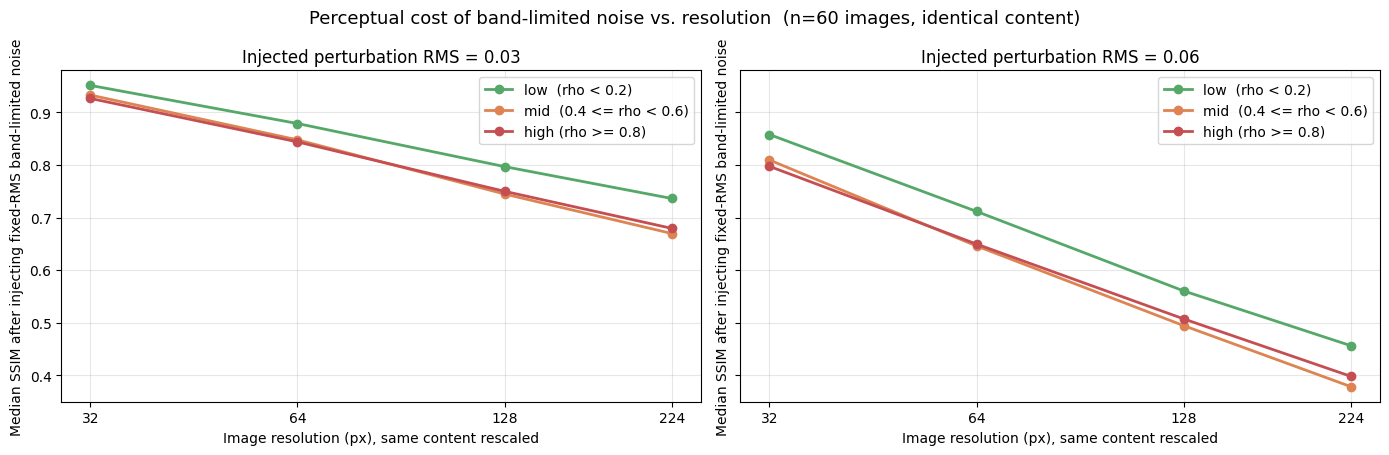

resolution                              32      64     128     224  \
band                    target_rms                                   
high (rho >= 0.8)       0.03        0.9266  0.8439  0.7499  0.6794   
                        0.06        0.7974  0.6496  0.5073  0.3981   
low  (rho < 0.2)        0.03        0.9513  0.8789  0.7969  0.7363   
                        0.06        0.8579  0.7117  0.5605  0.4563   
mid  (0.4 <= rho < 0.6) 0.03        0.9329  0.8478  0.7448  0.6697   
                        0.06        0.8095  0.6460  0.4945  0.3785   

resolution                          delta_32_to_224  
band                    target_rms                   
high (rho >= 0.8)       0.03                -0.2471  
                        0.06                -0.3994  
low  (rho < 0.2)        0.03                -0.2151  
                        0.06                -0.4016  
mid  (0.4 <= rho < 0.6) 0.03                -0.2633  
                        0.06                -0.4310  


In [13]:
# Median SSIM vs. resolution, one line per band, one panel per perturbation-RMS level --
# if the "HF occupies a disproportionate share of a small image" hypothesis were right, the
# high-frequency line should visibly separate from (fall off faster/slower than) the others.
fig, axes = plt.subplots(1, len(PERTURB_RMS), figsize=(7 * len(PERTURB_RMS), 4.6), sharey=True)
axes = np.atleast_1d(axes)
band_keys   = list(RES_BANDS)
band_colors = {band_keys[0]: '#55A868', band_keys[1]: '#DD8452', band_keys[2]: '#C44E52'}

for ax, rms in zip(axes, PERTURB_RMS):
    sub = res_df[res_df['target_rms'] == rms]
    for band_label, color in band_colors.items():
        g = sub[sub['band'] == band_label].groupby('resolution')['ssim'].median()
        ax.plot(g.index, g.values, marker='o', lw=2, color=color, label=band_label)
    ax.set_xscale('log', base=2)
    ax.set_xticks(RESOLUTIONS); ax.set_xticklabels(RESOLUTIONS)
    ax.set_xlabel('Image resolution (px), same content rescaled')
    ax.set_ylabel('Median SSIM after injecting fixed-RMS band-limited noise')
    ax.set_title(f'Injected perturbation RMS = {rms}')
    ax.legend()
    ax.grid(alpha=0.3)
plt.suptitle(f'Perceptual cost of band-limited noise vs. resolution  (n={N_RES_IMAGES} images, identical content)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/resolution_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# Slope summary: how much does SSIM change from 32px -> 224px, per band? A more negative
# delta means that band's perceptual cost grows faster (SSIM drops more) as resolution increases.
piv = res_df.groupby(['band', 'target_rms', 'resolution'])['ssim'].median().unstack('resolution')
piv['delta_32_to_224'] = piv[224] - piv[32]
print(piv.round(4))

## Summary & Open Questions

**Part A — band sensitivity.** The two models have **qualitatively different, almost mirror-image** frequency sensitivities:
* **Standard WRN-28-10**: monotonically cheaper (lower L2, higher SSIM) to cross the boundary as frequency *increases* — high-frequency band-limited noise is ~4× more energy-efficient and visually unobtrusive than low-frequency noise. This matches the broader literature on standard CNNs' well-documented high-frequency sensitivity, and suggests a **band-limited high-frequency direction would be a strictly better Phase-1 initializer than the current corruption-family approach** for this model.
* **Robust (TRADES) WRN-28-10**: roughly flat across bands, mildly *favoring low/mid* frequencies and *disfavoring* high — the opposite ranking — and uniformly 4–8× harder to attack with 2× lower SSIM at the boundary than the standard model. Adversarial training appears to have both flattened *and inverted* the frequency profile of the decision boundary. **No band gives Phase 1 a meaningful edge here**; the bulk of the attack's cost will sit in Phase 3 regardless of initialization frequency.

**Part B — resolution dependence.** Holding the *per-pixel* RMS of the injected band-limited noise constant and rescaling the same images from 32px → 224px:

| band | RMS=0.03 (Δ SSIM, 32→224px) | RMS=0.06 (Δ SSIM, 32→224px) |
|---|---:|---:|
| low (ρ<0.2)   | −0.215 | −0.402 |
| mid (0.4≤ρ<0.6) | −0.263 | −0.431 |
| high (ρ≥0.8)  | −0.247 | −0.399 |

All three bands degrade in **near lock-step** as resolution grows (the spread between bands, ≤0.05 SSIM, is small relative to the overall ≈0.2–0.43 drop, and high-frequency is *not* the band that falls off fastest — mid-frequency is). **This does not support the report's "HF components occupy a disproportionate share of a 32×32 image, making them comparatively more perceptually costly there" mechanism as a purely perceptual (SSIM-measurable) phenomenon** — band-limited noise's perceptual geometry scales almost uniformly with resolution, independent of which band it occupies.

*(Caveat: SSIM gets uniformly **worse**, not better, at higher resolutions here — because holding *per-pixel* RMS constant means the perturbation's *total* L2 energy grows with the pixel count. That's an artifact of this normalization choice and applies equally to all bands, so it doesn't change the comparison *between* bands, which is the point of this test.)*

**Putting A and B together**: the resolution-dependent story in the report is probably better explained as a **model/architecture-dependent** phenomenon than a generic image-perceptual one — exactly what Part A already demonstrates directly (two models at the *same* 32×32 resolution have opposite frequency-sensitivity profiles). A natural follow-up, if a higher-resolution CIFAR-trained or ImageNet model becomes available, would be to re-run Part A's *exact* band-sensitivity sweep at that resolution and check whether the *band that the model is most sensitive to* shifts with resolution — that would be the direct test of the report's claim, rather than a proxy via human-perceptual SSIM.

**Outputs saved to** `outputs/study3_frequency/`:
* `band_directions_example.png` — visual sanity check of the band-limited directions
* `band_sensitivity.png`, `band_efficiency.png`, `band_sensitivity.parquet` — Part A
* `resolution_dependence.png`, `resolution_sweep.parquet` — Part B

**Follow-ups this raises** (candidates for later stages):
* A **band-limited high-frequency initializer** (replacing or augmenting the corruption-family Phase 1) is now a concretely motivated, testable improvement for attacking the *standard* model — it should reach the boundary in far fewer queries and at much higher SSIM than the current best corruption family member.
* Because the standard and robust models have such different frequency profiles, **Phase 1 may benefit from being model-aware** (e.g., briefly probing a couple of bands before committing to one) rather than using a single fixed corruption family for both.
* The same vectorised-binary-search machinery (Part A, cell 7) generalises directly to comparing *any* set of candidate Phase-1 directions at scale — useful infrastructure for Studies 1 and 2.